# MI Datasets: Core Pipeline & Spatial Tracking
This tutorial demonstrates how to load datasets, apply Tracked Transforms, and use the spatial inverse mapping to project tensor activations back into the original raw data space.

In [1]:
import torch
import matplotlib.pyplot as plt
from mi_datasets import load_dataset
from mi_datasets.modalities.vision.transforms import (
    TrackedCompose, 
    TrackedRandomCrop, 
    TrackedNormalize,
    TrackedToTensor
)

### 1. Initialization and Tracked Transforms
We define a pipeline of `TrackedTransforms`. Unlike standard `torchvision` transforms, these intercept and log the stochastic parameters (e.g., exact crop coordinates) used during the forward pass.

In [2]:
# 1. Define the MI transform pipeline
pipeline = TrackedCompose([
    TrackedRandomCrop(size=(24, 24)),
    TrackedToTensor(),
    TrackedNormalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

# 2. Load the dataset (using a tiny subset for rapid prototyping)
dataset = load_dataset(
    "torchvision/cifar10", 
    split="train", 
    subset_fraction=0.01,
    transform=pipeline
)

print(dataset.get_info())

Dataset: CIFAR10 [vision]
Provider: CIFAR10Dataset
Split: train | Total Items: 500
------------------------------
Features:
  • id: int
  • input: Image
  • target: Tensor
  • metadata: dict

Input Transforms:
  • TrackedRandomCrop (Spatial: True)
      size: (24, 24)
  • TrackedToTensor (Spatial: False)
  • TrackedNormalize (Spatial: False)
      mean: (0.5, 0.5, 0.5)
      std: (0.5, 0.5, 0.5)

Metadata:
  • classes: [airplane, automobile, ..., truck] (len=10)
  • num_classes: 10


/Users/erik/Desktop/PROJECTS/research-harness/mi_datasets/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


### 2. The Forward Pass and Metadata Tracking
When we fetch an item, the framework executes the pipeline and populates the `metadata` dictionary with the exact transform history.

In [3]:
# Fetch a single DataItem
item = dataset[0]

print(f"Dataset ID: {item.id}")
print(f"Raw Input Type: {type(item.raw_input)}")
print(f"Model Input Shape: {item.model_input.shape}")

# Inspect the tracking history
history = item.metadata["transform_history"]
print("\nTransform History:")
for step in history:
    print(f" - {step['name']}: {step['params']}")

Dataset ID: 264
Raw Input Type: <class 'PIL.Image.Image'>
Model Input Shape: torch.Size([3, 24, 24])

Transform History:
 - TrackedRandomCrop: {'crop_top': 6, 'crop_left': 4, 'crop_h': 24, 'crop_w': 24, 'orig_h': 32, 'orig_w': 32}
 - TrackedToTensor: {}
 - TrackedNormalize: {'mean': (0.5, 0.5, 0.5), 'std': (0.5, 0.5, 0.5)}


### 3. Mechanistic Inversion
To interpret a model's internal activations, we must project them back to the original input space. Here, we simulate a hypothetical activation mask (e.g., an attention head focusing on the center of the cropped tensor) and map it backward through the `TrackedCompose` pipeline.

In [4]:
# Simulate a downstream activation map (e.g., a 24x24 attention mask)
# We fill it with 1s to represent the active receptive field
simulated_activation = torch.ones(1, 24, 24)

# Execute the inverse mapping using the logged history
inverted_mask = pipeline.inverse(simulated_activation, history)

print(f"Original Mask Shape: {simulated_activation.shape}")
print(f"Inverted Mask Shape: {inverted_mask.shape}")

Original Mask Shape: torch.Size([1, 24, 24])
Inverted Mask Shape: torch.Size([3, 32, 32])


### 4. Visualizing the Projection
We visualize the raw PIL image alongside our mathematically inverted mask. The mask perfectly aligns with the specific stochastic crop applied during the forward pass.

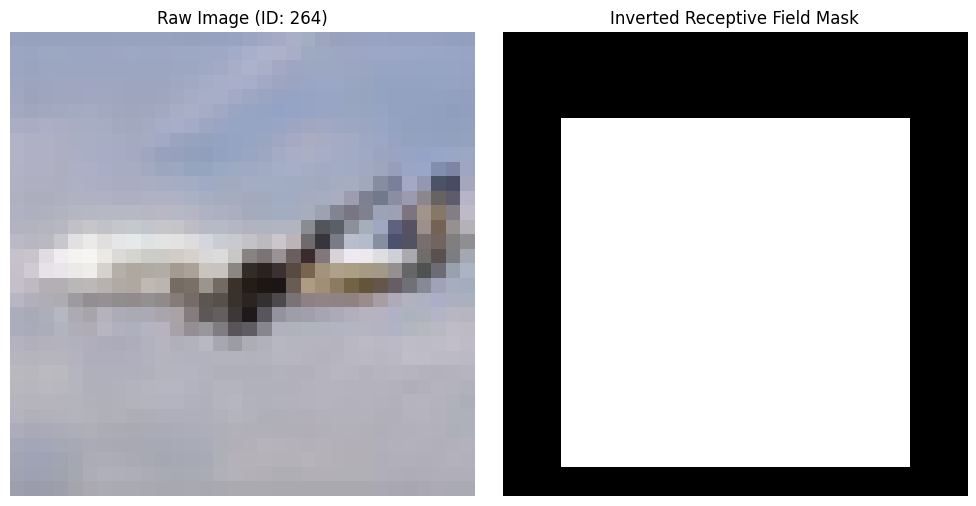

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(item.raw_input)
axes[0].set_title(f"Raw Image (ID: {item.id})")
axes[0].axis("off")

# The padded areas (lost during cropping) are 0.0 (black)
# The retained areas are 1.0 (white)
axes[1].imshow(inverted_mask[0].numpy(), cmap="gray")
axes[1].set_title("Inverted Receptive Field Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 5. Reproducible Experiments via YAML Configs
The `load_dataset` function is polymorphic: if you pass it a YAML file, it will automatically parse the file, extract the dataset identifier, and merge the parameters.

Let's dynamically write a configuration file to disk and load it.

In [6]:
config_path = "../configs/torchvision_cifar10.yaml"
ds2 = load_dataset(config_path)

print(ds2.get_info())

Dataset: CIFAR10 [vision]
Provider: CIFAR10Dataset
Split: train | Total Items: 50000
------------------------------
Features:
  • id: int
  • input: Image
  • target: Tensor
  • metadata: dict

Metadata:
  • classes: [airplane, automobile, ..., truck] (len=10)
  • num_classes: 10


### 6. Extending the Framework: Adding a Custom Dataset
To add a new dataset, you do not need to modify the core framework code. You simply subclass `BaseMIDataset`, implement the required data-fetching methods, and decorate it with `@register_dataset`.

Here is an example of creating a synthetic vision dataset completely from scratch.

In [7]:
from typing import Dict, Any
from mi_datasets.core.registry import register_dataset
from mi_datasets.core.base import BaseMIDataset

@register_dataset("custom/synthetic")
class SyntheticDataset(BaseMIDataset):
    _modality = "vision"

    def _is_cached(self, required_files=None) -> bool:
        # For a synthetic dataset, we don't need disk caching
        return True 

    def _download(self) -> None:
        # If this were a real dataset, we'd write to self.cache_dir here
        pass

    def _load_into_memory(self) -> None:
        # Generate 100 random synthetic images and labels in memory
        torch.manual_seed(42)
        self.images = torch.rand(100, 3, 32, 32)
        self.labels = torch.randint(0, 5, (100,))

    def _get_full_length(self) -> int:
        return 100

    def _get_raw_data(self, idx: int) -> Dict[str, Any]:
        return {
            "id": f"synth_{idx}",
            "input": self.images[idx],
            "target": self.labels[idx],
            "metadata": {"source": "belongs to the clankers"}
        }

    def _get_modality_metadata(self) -> Dict[str, Any]:
        return {"num_classes": 5, "is_synthetic": True}

Once registered, the dataset is immediately available to the global `load_dataset` factory and natively supports all core framework features (caching, deterministic subsetting, MI transform tracking, and string formatting).

In [8]:
# Instantiate our newly registered dataset
custom_ds = load_dataset("custom/synthetic", subset_fraction=0.5)

print(custom_ds.get_info())

# Fetch an item to prove the contract is upheld
custom_item = custom_ds[0]
print(f"\nFetched ID: {custom_item.id}")
print(f"Tensor Shape: {custom_item.model_input.shape}")

Dataset: SYNTHETIC [vision]
Provider: SyntheticDataset
Split: train | Total Items: 50
------------------------------
Features:
  • id: str
  • input: Tensor
  • target: Tensor
  • metadata: dict

Metadata:
  • num_classes: 5
  • is_synthetic: True

Fetched ID: synth_4
Tensor Shape: torch.Size([3, 32, 32])


### 7. Custom Transformations
The `TrackedCompose` class supports standard torchvision transforms alongside the tracked variants.

**Warning:** Mixing tracked and non-tracked transforms is fine as long as the non-tracked versions are not spatial transforms. Mixing non-tracked spatial transforms will compromise the `.inverse()` functionality and lead to misaligned mappings.

In [9]:
import torchvision.transforms.v2 as v2

mixed_pipeline = TrackedCompose([
    TrackedRandomCrop(size=(24, 24)),           # Tracked (Spatial)
    v2.ColorJitter(brightness=0.2),             # Standard (Value)
    v2.RandomHorizontalFlip(p=0.5),             # Standard (Spatial) - DANGER!
    TrackedToTensor(),                          # Tracked (Value)
])

/Users/erik/Desktop/PROJECTS/research-harness/mi_datasets/src/mi_datasets/modalities/vision/transforms.py:61: UserWarning: 
[MI WARNING] Standard 'RandomHorizontalFlip' detected.
The framework has a built-in tracked alternative for this. Please import and use 'TrackedRandomHorizontalFlip' instead to maintain spatial inversion.
  warnings.warn(


If you need a specific spatial augmentation (like translation or shear) that isn't built into the framework, you can easily create your own. 

You must subclass `TrackedTransform` and adhere to three rules:
1. **The Tuple Contract:** The forward pass (`__call__`) must return a tuple of `(transformed_tensor, params_dict)`.
2. **JSON-Serializable:** The `params_dict` must contain ONLY native Python types (`int`, `float`, `bool`). Do not store PyTorch tensors in the parameters. Call `.item()` to extract scalars.
3. **Stateless Execution:** Do not save parameters as class attributes (`self.shift_x = ...`). PyTorch DataLoaders use multiprocessing; storing state on the class will cause race conditions and corrupt your tracking history.

In [10]:
from typing import Dict, Tuple, Any
from mi_datasets.modalities.vision.transforms import TrackedTransform

class TrackedRandomShift(TrackedTransform):
    """Randomly shifts an image spatially and tracks the exact pixel offset."""
    
    def __init__(self, max_shift: int):
        self.max_shift = max_shift

    def __call__(self, img: torch.Tensor) -> Tuple[torch.Tensor, Dict[str, Any]]:
        # 1. Generate stochastic parameters (extracting to raw Python ints)
        shift_x = int(torch.randint(-self.max_shift, self.max_shift + 1, (1,)).item())
        shift_y = int(torch.randint(-self.max_shift, self.max_shift + 1, (1,)).item())
        
        # 2. Apply the forward transformation (assuming CHW format)
        shifted_img = torch.roll(img, shifts=(shift_y, shift_x), dims=(1, 2))
        
        # 3. Package the parameters
        params = {
            "shift_x": shift_x, 
            "shift_y": shift_y
        }
        
        return shifted_img, params

    def inverse(self, x: torch.Tensor, params: Dict[str, Any]) -> torch.Tensor:
        # 1. Retrieve the exact parameters used in the forward pass
        shift_x = params["shift_x"]
        shift_y = params["shift_y"]
        
        # 2. Apply the mathematical inverse (shift in the opposite direction)
        return torch.roll(x, shifts=(-shift_y, -shift_x), dims=(1, 2))

Let's test our custom `TrackedRandomShift` independently to prove that the forward and inverse mappings are mathematically sound.

In [11]:
custom_transform = TrackedRandomShift(max_shift=15)
dummy_input = torch.rand(3, 32, 32)

# Execute the forward pass
shifted_tensor, tracked_params = custom_transform(dummy_input)

print(f"Tracked Parameters: {tracked_params}")

# Execute the inverse pass
restored_tensor = custom_transform.inverse(shifted_tensor, tracked_params)

# Because translation doesn't crop or destroy pixels, the inverse should be a 1:1 perfect match
is_exact_match = torch.allclose(dummy_input, restored_tensor)
print(f"Inverse = Input: {is_exact_match}")

Tracked Parameters: {'shift_x': -5, 'shift_y': -8}
Inverse = Input: True


In [12]:
dl = dataset.get_dataloader(batch_size=8, shuffle=True)

In [13]:
batch = next(iter(dl))

In [14]:
batch

DataBatch(ids=[21814, 8790, 38794, 13940, 1529, 23414, 47492, 21962], model_inputs=tensor([[[[ 0.5373,  0.4275,  0.4431,  ..., -0.9059, -0.9059, -0.8118],
          [ 0.5059,  0.4588,  0.4118,  ..., -0.9373, -0.9373, -0.8431],
          [ 0.4118,  0.5216,  0.4118,  ..., -0.9059, -0.9373, -0.8902],
          ...,
          [-0.7961, -0.7725, -0.7882,  ...,  0.2078,  0.3647,  0.3569],
          [-0.5608, -0.7020, -0.7569,  ...,  0.0745,  0.3490,  0.3647],
          [-0.0196, -0.1686, -0.7255,  ..., -0.1373,  0.1451,  0.3647]],

         [[ 0.1294, -0.0902, -0.1059,  ..., -0.9059, -0.9059, -0.8039],
          [ 0.1137,  0.0196, -0.1137,  ..., -0.9451, -0.9373, -0.8431],
          [-0.0118,  0.1373, -0.1137,  ..., -0.9059, -0.9451, -0.9059],
          ...,
          [-0.7725, -0.7647, -0.7882,  ...,  0.3255,  0.3725,  0.3569],
          [-0.5529, -0.7098, -0.7569,  ...,  0.0431,  0.3333,  0.3725],
          [-0.0196, -0.1608, -0.7255,  ..., -0.2000,  0.0902,  0.3647]],

         [[-0.1922,

In [15]:
batch[0]

TypeError: 'DataBatch' object is not subscriptable